# libraries


In [1]:
import pandas as pd
import numpy as np
import math
from math import floor
import scipy
import matplotlib.pyplot as plt
import sklearn 
import xarray as xr
from sklearn.tree import DecisionTreeRegressor
import matplotlib.patches as mpl_patches

import os

os.chdir('C:/Users/leoge/OneDrive/Documents/Centrale Nantes/ei4/R&D')

# SETUP

## functions

In [2]:
def cross_score(model, X, y ):
        """ Arguments 
        - model
        - X features
        - y target
        Returns
        cross val score for R-squared (r2), 
        mean absolute value (mae),
        mean square error (mse),
        root mean squared error (rmse)
        """
        from sklearn.model_selection import LeaveOneOut, cross_val_score
        cv=LeaveOneOut()
        r2=cross_val_score(model,X,y, scoring='r2',cv=cv,n_jobs=-1)

        mae=cross_val_score(model,X,y,
                            scoring='neg_mean_absolute_error',
                            cv=cv, 
                            n_jobs=-1) 
        mse=cross_val_score(model,X,y,
                                scoring='neg_mean_squared_error',
                                cv=cv,
                                n_jobs=-1)
        rmse=cross_val_score(model,X,y,
                                scoring='neg_root_mean_squared_error',
                                cv=cv,
                                n_jobs=-1)

        df=pd.DataFrame(data={'r2':r2,'mae':mae,'mse':mse,'rmse':rmse})
        return df

## setup definition

In [3]:
# time span
time_range_min=-12000 #a cal. years BP
time_range_max=0   #in cal. years BP 0 = 1950 AD (Anno Domini: "après JC")
# spatial span ; span used in the paper
lat_min,lat_max=45,55 # degree north
lon_min,lon_max=90,100 # degree east

# measurments lakes
lakes=['M14','M15','O6','O14','O15','O16']
lat=[50.0755555556,49.7858333333,49.8213888889,50.0283333333,50.0080555556,50.0186111111]
lon=[-95.4022222222,-95.1902777778,-94.7836111111,-94.8244444444,-94.9825,-94.8508333333]
altitude=[330,337,361,332,339,337]
measurments=pd.DataFrame({'Lake':lakes,'lat':lat,'lon':lon,'altitude':altitude})

lat_meas=measurments.describe().loc['mean'].lat
lon_meas=measurments.describe().loc['mean'].lon
lat_meas,lon_meas #degree north, degree east

time_resolution= 50 #in a cal. years BP
time_array=np.arange(time_range_min,time_range_max+time_resolution,time_resolution ) #in cal. years BP

roll_window=10
size_test=0.25


## Load PRECT and TS data

In [4]:
#Precipitation rate #decadal mean annual # averages 22ka-2000AD 
#PRECT = Total precipitation rate: PRECC+PRECL #PRECC = Convective precipitation rate #PRECL = Large-scale (stable) precipitation rate

PRECT = xr.open_dataset(
    './climate_data/TraCE-21K-II.ann.PRECT.nc')
PRECT = PRECT.sel(lat=lat_meas,lon=360+lon_meas,method='nearest')
PRECT=PRECT.rename({'time':'Age'})
PRECC = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECC':PRECT.PRECC.values})
PRECL = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECL':PRECT.PRECL.values})
PRECT = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECT':PRECT.PRECT.values})

#Temperature Surface
TS = xr.open_dataset(
    './climate_data/TraCE-21K-II.ann.TS.nc')
TS = TS.sel(lat=lat_meas,lon=360+lon_meas,method='nearest')
TS=TS.rename({'time':'Age'})
TS = pd.DataFrame({'Age':TS.Age.values*1000,'TS':TS.TS.values})

AnnTemp = pd.read_csv('./25155593/AnnTemp.csv')
AnnTemp=AnnTemp[['Age','AnnTemp']].dropna()
AnnTemp = AnnTemp.reindex(index=AnnTemp.index[::-1]).reset_index(drop=True)
AnnTemp.Age=AnnTemp.Age*(-1)
Human = pd.read_csv('./25155593/Human.csv')
Human = Human.reindex(index = Human.index[::-1]).reset_index(drop=True)
Human.Age = Human.Age /(-1) #conversion to 12000 to 0 

## Load fire data

In [5]:
# Fire frequency
FF = pd.read_csv('./25155593/FFBootCISap.csv')
FF= FF.reindex(index=FF.index[::-1]).reset_index(drop=True)
FF.Age = FF.Age /(-1)
# burning biomass
BB = pd.read_csv('./25155593/BBBootCISap.csv')
BB = BB.reindex(index=BB.index[::-1]).reset_index(drop=True)
BB.Age = BB.Age/(-1)
#FS = FF/BB
FS = pd.read_csv('./25155593/FSBootCISap.csv')
FS = FS.reindex(index=FS.index[::-1]).reset_index(drop=True)
FS.Age = FS.Age/(-1)

FF=FF.rename(columns={'Mean':'FF_Mean'})
FS=FS.rename(columns={'Mean':'FS_Mean'})
BB=BB.rename(columns={'Mean':'BB_Mean'})

<Axes: xlabel='Age'>

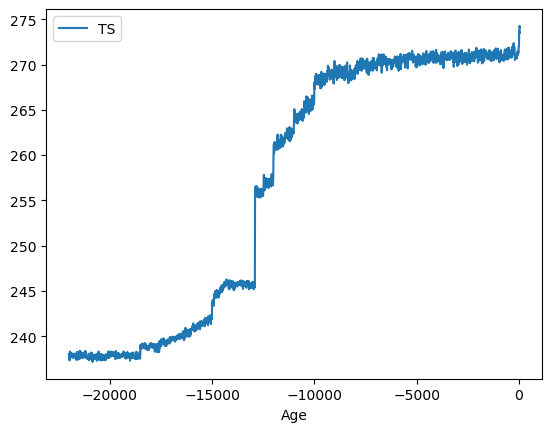

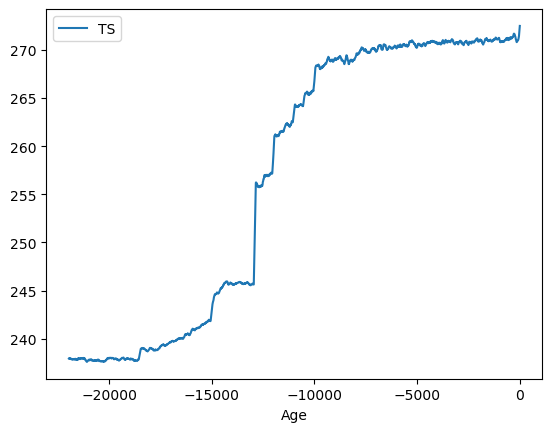

In [6]:
TS.plot(x='Age')
ds=TS.rolling(window=roll_window).mean()
ds.plot(x='Age',y='TS')

In [7]:
list_vars=['TS','PRECT','human'] # ,'PRECC','PRECL'
list_df=[TS,PRECT,Human] # ,PRECC,PRECL

dict={'Age':time_array}
for i in range (len(list_vars)):
    f_interp = np.interp(time_array,list_df[i].Age.values,list_df[i][list_vars[i]].values)
    mean_3_to_5_ka= list_df[i].loc[(list_df[i].Age < -3000) & (list_df[i].Age > -5000)][list_vars[i]].mean()
    f_interp = f_interp - mean_3_to_5_ka
    dict.update({list_vars[i]:f_interp})

list_df=[BB,FF,FS]
list_var= ['BB_Mean','FF_Mean','FS_Mean']
dict2={'Age':time_array}
n=len(list_df)
for i in range (0,n):
    f_interp = np.interp(time_array,list_df[i].Age.values,list_df[i][list_var[i]].values)
    dict2.update({list_var[i]:f_interp})

dict.update(dict2)

df_annual = pd.DataFrame(dict)
df_annual.Age = time_array # convert -12 ka to 12000 cal. years BP



In [8]:

df_annual = df_annual.rolling(window=roll_window).mean()
df_moy=df_annual.rolling(window=roll_window).mean()
# Age from 12000 to 0 cal. years BP with a 50 years time_step
# all data compared to the mean from 5000 to 3000 cal. yers BP (publication)
# TS in K
# PRECT, PRECC and PRECL in m/d (hence the 10E-9)

Text(0.5, 1.0, 'PRECT')

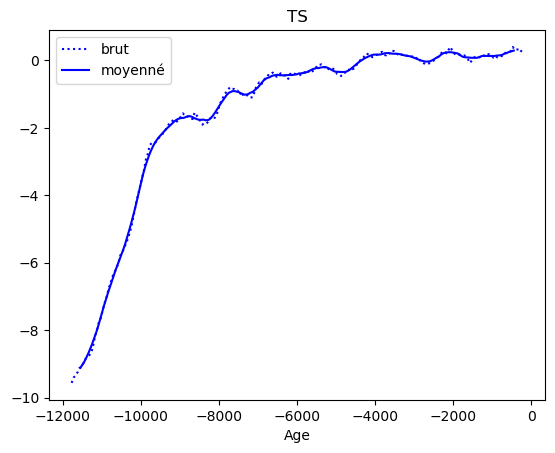

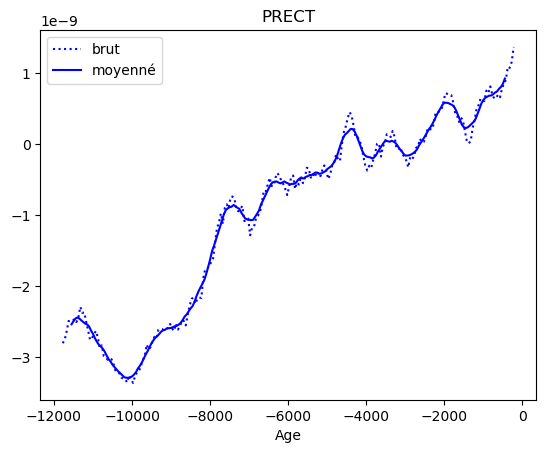

In [9]:
fig, ax=plt.subplots()

df_annual.plot(x='Age',y='TS',ax=ax,label='brut',linestyle=':',color='b')
df_moy.plot(x='Age',y='TS',ax=ax,label='moyenné',color='b')
ax.set_title('TS')

fig, ax=plt.subplots()

df_annual.plot(x='Age',y='PRECT',ax=ax,label='brut',linestyle=':',color='b')
df_moy.plot(x='Age',y='PRECT',ax=ax,label='moyenné',color='b')
ax.set_title('PRECT')

## Load pollen data

In [10]:
Pollen50Reg = pd.read_csv('./25155593/Pollen50Reg.csv')
Pollen50Reg
pollen = Pollen50Reg

cols_pollen=Pollen50Reg.columns

Pollen50Reg.Age = Pollen50Reg.Age # turn age into -12 to 0 ka cal. years BP (same as environmental data)
Pollen50Reg = Pollen50Reg.iloc[::-1].reset_index(drop=True)

time_pollen= time_array #np.arange(0,np.max(Pollen50Reg.Age.values),50)
df=Pollen50Reg
df.Age=df.Age*(-1)
cols=df.columns
dict = {'Age':time_pollen}
for x in cols:
    fp=df[x].values
    f_interp=np.interp(x=time_pollen,xp=df.Age,fp=fp)
    dict.update({x:f_interp})

Pollen50Reg=pd.DataFrame(dict)
Pollen50Reg.Age=Pollen50Reg.Age
Pollen50Reg = Pollen50Reg.rolling(window=roll_window).mean()
pollen_smooth = Pollen50Reg.rolling(window=roll_window).mean()


# type of plants by family
conifers = Pollen50Reg.columns[1:6]
deciduous = Pollen50Reg.columns[6:12]
herbaceous = Pollen50Reg.columns[12:-1]
aquatics =Pollen50Reg.columns[-1:]


Text(0.5, 1.0, 'Herbaceous')

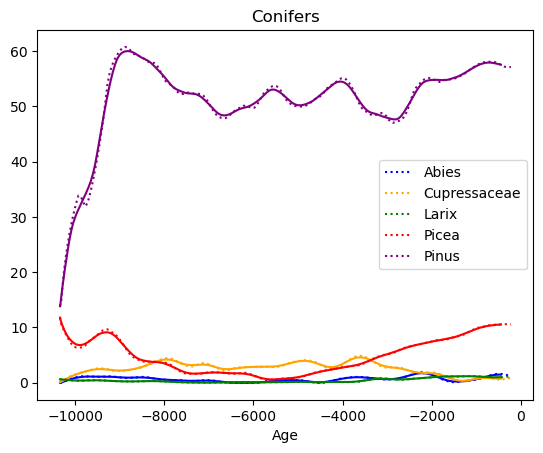

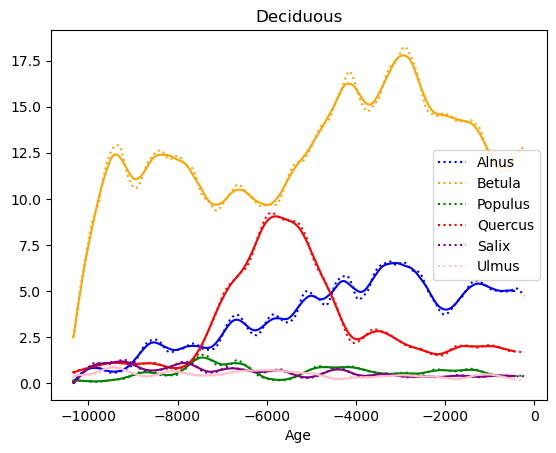

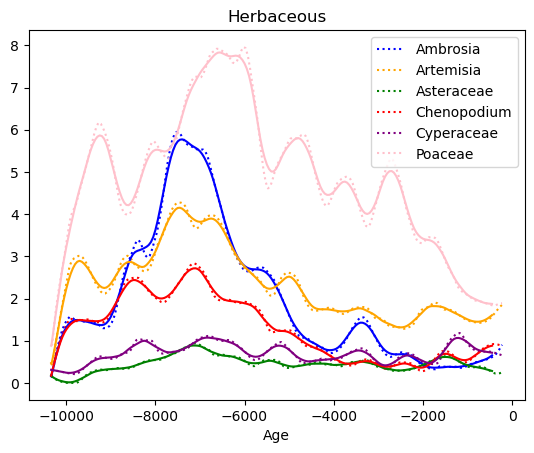

In [11]:
fig,ax=plt.subplots()

# dss= pd.read_csv('./25155593/Pollen50Reg.csv')
Pollen50Reg.plot(x='Age',y=conifers,ax=ax,linestyle=':',color=['b','orange','g','r','purple'])

pollen_smooth.plot(x='Age',y=conifers,ax=ax,linestyle='-',color=['b','orange','g','r','purple'])
ax.legend(conifers)
ax.set_title('Conifers')

fig,ax=plt.subplots()

# dss= pd.read_csv('./25155593/Pollen50Reg.csv')
Pollen50Reg.plot(x='Age',y=deciduous,ax=ax,linestyle=':',color=['b','orange','g','r','purple','pink'])

pollen_smooth.plot(x='Age',y=deciduous,ax=ax,linestyle='-',color=['b','orange','g','r','purple','pink'])
ax.legend(deciduous)
ax.set_title('Deciduous')

fig,ax=plt.subplots()

# dss= pd.read_csv('./25155593/Pollen50Reg.csv')
Pollen50Reg.plot(x='Age',y=herbaceous,ax=ax,linestyle=':',color=['b','orange','g','r','purple','pink'])

pollen_smooth.plot(x='Age',y=herbaceous,ax=ax,linestyle='-',color=['b','orange','g','r','purple','pink'])
ax.legend(herbaceous)
ax.set_title('Herbaceous')

# Linear model

## merge

In [13]:
df_data = pd.merge(Pollen50Reg, df_annual, how='inner', on=['Age', 'Age'])
array_age=df_data.Age.values

In [14]:
df_data=df_data.dropna()

In [22]:
df_data.columns[1:-3]
df_data.columns[-3:]


Index(['BB_Mean', 'FF_Mean', 'FS_Mean'], dtype='object')

Text(0.5, 1.0, 'Pearson correlation with environmental')

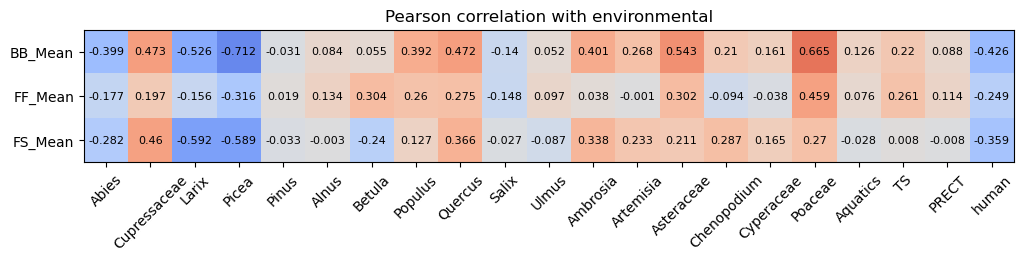

In [25]:
mat_pearson=df_data.corr(method='pearson').iloc[-3:,1:-3]
mat_pearson
fig, ax = plt.subplots(figsize=(12,6))
ax.imshow(mat_pearson,cmap='coolwarm',vmin=-1,vmax=1,origin='upper')
nrow,ncol=mat_pearson.shape
list_vars=df_data.columns[1:-3]

for i in range(nrow):
    for j in range(ncol):
        c=mat_pearson.iloc[i,j]
        ax.text(j,i,round(c,3),va='center',ha='center',color='k',size=8)

ax.set_xticks(np.arange(0,len(list_vars),1),labels=list_vars,size=10,rotation=45)       
ax.tick_params(axis="x", bottom=True,top=False, labelbottom=True,labeltop=False)
ax.set_yticks(np.arange(0,len(list_var),1),labels=list_var,size=10)  
ax.set_title('Pearson correlation with environmental')  

## train_test_split

R-squared: 0.8788891658561772
Mean squared error: 7.754760703360018e-05
Root mean squared error: 0.008806111913529159
Intercept: 0.6422836938864865

Feature Coefficients:
          Feature  Coefficient
0          Abies    -0.007930
1   Cupressaceae     0.000382
2          Larix    -0.050108
3          Picea     0.000441
4          Pinus    -0.003529
5          Alnus     0.008916
6         Betula    -0.015844
7        Populus    -0.021591
8        Quercus    -0.038435
9          Salix    -0.014458
10         Ulmus     0.003749
11      Ambrosia    -0.013524
12     Artemisia     0.009190
13    Asteraceae     0.004935
14   Chenopodium     0.005777
15    Cyperaceae     0.002809
16       Poaceae    -0.015432
17      Aquatics     0.009843
18            TS     0.005275
19         PRECT     0.023040
20         human    -0.014130


C:\Users\leoge\AppData\Local\Temp\ipykernel_18856\1988171429.py:179: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


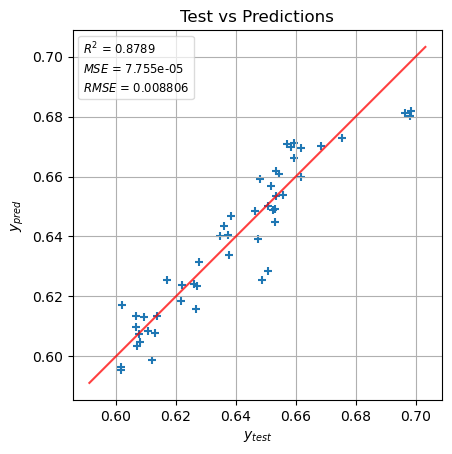

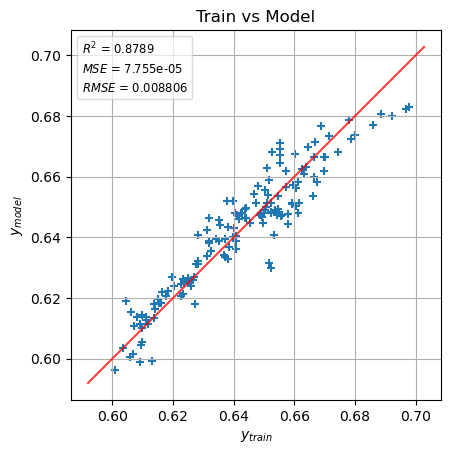

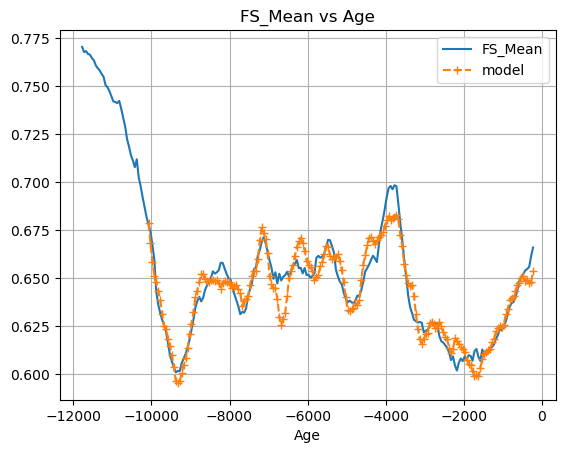

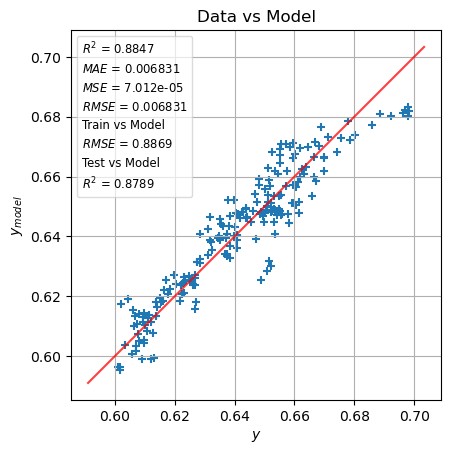

In [15]:
# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Create features X and target y.
features = df_data.columns.values[1:-3]
y_target=['FS_Mean']#,'FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]
    # Create features X and target y.


    # Split the dataset into training (usually 75%) and testing (25%) sets.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
    # tt=100
    # X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    # Fit and transform training data.
    X_train_scaled = scaler.fit_transform(X_train)   # X_train
    X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
    # Also transform test data.
    X_test_scaled = scaler.transform(X_test)    # X_test 
    X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ############ performance of model #################""
    # Calculate and print R^2 score.
    r2 = r2_score(y_test, y_pred)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    print(f"Root mean squared error: {rmse}")
    # accuracy = accuracy_score(y_test,y_pred)
    # print(f"Accuracy score: {accuracy:.4f}")

    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("Intercept:", model.intercept_)

    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("\nFeature Coefficients:\n", coeff_df)

    ############# plot correlation plots #######################
    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel(r'$y_{test}$')
    ax.set_ylabel(r'$y_{pred}$')
    ax.set_title('Test vs Predictions')
    # squared plot
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # create a list with two empty handles (or more if needed)
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    ############ plot for train data #################
    # model for X_train
    df_model_train=X_train_scaled
    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
    # add all columns 
    df_model_train = df_model_train.sum(axis=1)

    fig, ax = plt.subplots()

    ax.scatter(x=y_train,y=b+df_model_train,marker='+')
    ax.set_xlabel(r'$y_{train}$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Train vs Model')
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()

    # r2 = r2_score(y_train, b+df_model_train)
    # print(f"R-squared: {r2}")
    # # Calculate and print MSE.
    # mse = mean_squared_error(y_train, b+df_model_train)
    # print(f"Mean squared error: {mse}")
    # # Calculate and print RMSE.
    # rmse = mse ** 0.5
    # handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
    #                                 lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    # labels = []#"R-squared: {r2}"
    # labels.append('$R^2$ = {0:.4g}'.format(r2) )
    # labels.append('$MSE$ = {0:.4g}'.format(mse) )
    # labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    #### dataframe of obtained model
    df_model=X
    X_scaled=scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]

    # add all columns 
    df_model = df_model.sum(axis=1)

    # figure
    fig, ax = plt.subplots()
    df_annual.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_data['Age'],b+df_model,label='model',marker='+',linestyle='--')
    ax.legend()
    ax.set_title(y_target[k] +' vs Age')
    ax.grid()

    fig, ax = plt.subplots()
    ax.scatter(x=y,y=b+df_model,marker='+')
    ax.set_xlabel(r'$y$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Data vs Model')
    ax.set_aspect('equal',adjustable='box')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # Calculate and print R^2 score.
    r2 = r2_score(y, b+df_model)
    mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 8

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MAE$ = {0:.4g}'.format(mae) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
    labels.append('Train vs Model' )
    r2 = r2_score(y_train, b+df_model_train)
    labels.append('$RMSE$ = {0:.4g}'.format(r2) )
    labels.append('Test vs Model' )
    r2 = r2_score(y_test, y_pred)
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    




    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)


In [16]:
FF_smooth_coeff = coeff_df

### comparaison coeff données brut et lissées

In [17]:
FF_coeff = pd.DataFrame(data={'Feature':np.array(['Abies', 'Cupressaceae', 'Larix', 'Picea', 'Pinus', 'Alnus',
       'Betula', 'Populus', 'Quercus', 'Salix', 'Ulmus', 'Ambrosia',
       'Artemisia', 'Asteraceae', 'Chenopodium', 'Cyperaceae', 'Poaceae',
       'Aquatics', 'TS', 'PRECT', 'human'], dtype=object),'Coefficient':np.array([ 1.58260474e-04, -3.32723166e-04,  2.70102950e-04, -4.94862167e-04,
        1.50657814e-04, -1.25163839e-04,  2.59412198e-04, -3.70011477e-05,
        2.60082178e-05, -2.30391612e-05, -2.89866350e-05, -3.31191144e-05,
        3.92558758e-05,  1.78239976e-04, -2.54716913e-04, -1.05365993e-04,
        5.26078998e-04, -5.61083931e-05, -3.71438277e-05, -1.42752480e-04,
        7.16856051e-05],dtype=float)})

FS_coeff = pd.DataFrame(data={'Feature':np.array(['Abies', 'Cupressaceae', 'Larix', 'Picea', 'Pinus', 'Alnus',
       'Betula', 'Populus', 'Quercus', 'Salix', 'Ulmus', 'Ambrosia',
       'Artemisia', 'Asteraceae', 'Chenopodium', 'Cyperaceae', 'Poaceae',
       'Aquatics', 'TS', 'PRECT', 'human'], dtype=object),'Coefficient':np.array([-0.0035528 ,  0.00756938, -0.02567408,  0.00041581,  0.00071621,
       -0.00080135, -0.01068787, -0.00365177, -0.01494428, -0.01437672,
        0.00093189, -0.0024144 , -0.00470529, -0.0069179 ,  0.00233813,
        0.00223273, -0.00637114,  0.01331868, -0.00018705,  0.00973044,
       -0.00808267],dtype=float)})

FF_coeff_smooth = pd.DataFrame(data={'Feature':np.array(['Abies', 'Cupressaceae', 'Larix', 'Picea', 'Pinus', 'Alnus',
       'Betula', 'Populus', 'Quercus', 'Salix', 'Ulmus', 'Ambrosia',
       'Artemisia', 'Asteraceae', 'Chenopodium', 'Cyperaceae', 'Poaceae',
       'Aquatics', 'TS', 'PRECT', 'human'], dtype=object),'Coefficient':np.array([ 2.66761506e-04, -3.54672727e-04,  7.18949076e-04, -6.60720606e-04,
        1.59254193e-04, -1.97335522e-04,  2.00517843e-04,  7.40901529e-05,
        2.69150554e-04,  3.51545379e-05, -1.19861016e-04,  1.24141933e-04,
       -7.03686096e-05,  2.10953180e-04, -5.27596286e-04, -7.32873745e-05,
        7.20220922e-04, -1.31933492e-04,  9.24843780e-05, -5.95849715e-04,
        1.25315690e-04],dtype=float)})

FS_coeff_smooth = pd.DataFrame(data={'Feature':np.array(['Abies', 'Cupressaceae', 'Larix', 'Picea', 'Pinus', 'Alnus',
       'Betula', 'Populus', 'Quercus', 'Salix', 'Ulmus', 'Ambrosia',
       'Artemisia', 'Asteraceae', 'Chenopodium', 'Cyperaceae', 'Poaceae',
       'Aquatics', 'TS', 'PRECT', 'human'], dtype=object),'Coefficient':np.array([-0.00792971,  0.00038198, -0.05010789,  0.00044108, -0.00352892,
        0.0089164 , -0.01584417, -0.02159147, -0.03843509, -0.01445776,
        0.00374909, -0.01352357,  0.00918988,  0.00493531,  0.0057772 ,
        0.00280896, -0.01543235,  0.00984324,  0.00527466,  0.02304035,
       -0.01412952],dtype=float)})



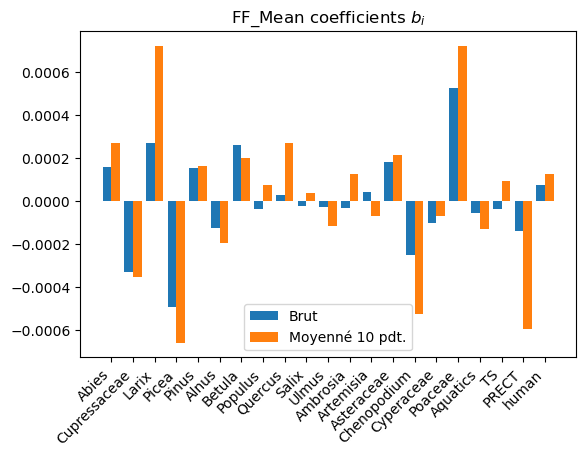

In [18]:
fig, ax = plt.subplots()

feature = FF_coeff.Feature
v1, v2 = FF_coeff.Coefficient.values, FF_coeff_smooth.Coefficient.values
w, x = 0.4, np.arange(len(feature))

ax.bar(x - w/2, v1, w, label='Brut')
ax.bar(x + w/2, v2, w, label='Moyenné 10 pdt.')

ax.set_xticks(x, feature)
# plt.ylabel('Va')
ax.set_title('FF_Mean coefficients $b_i$')
ax.legend()


# ax.bar(FF_coeff.Feature,[FF_coeff.Coefficient,FF_coeff_smooth.Coefficient])
fig.autofmt_xdate(rotation=45)

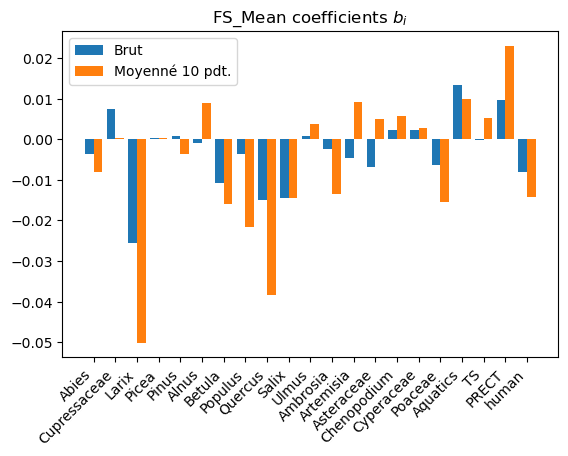

In [19]:
fig, ax = plt.subplots()

feature = FS_coeff.Feature
v1, v2 = FS_coeff.Coefficient.values, FS_coeff_smooth.Coefficient.values
w, x = 0.4, np.arange(len(feature))

ax.bar(x - w/2, v1, w, label='Brut')
ax.bar(x + w/2, v2, w, label='Moyenné 10 pdt.')

ax.set_xticks(x, feature)
# plt.ylabel('Va')
ax.set_title('FS_Mean coefficients $b_i$')
ax.legend()


# ax.bar(FF_coeff.Feature,[FF_coeff.Coefficient,FF_coeff_smooth.Coefficient])
fig.autofmt_xdate(rotation=45)

In [20]:
FF_smooth_coeff.Coefficient.values

array([-0.00792971,  0.00038198, -0.05010789,  0.00044108, -0.00352892,
        0.0089164 , -0.01584417, -0.02159147, -0.03843509, -0.01445776,
        0.00374909, -0.01352357,  0.00918988,  0.00493531,  0.0057772 ,
        0.00280896, -0.01543235,  0.00984324,  0.00527466,  0.02304035,
       -0.01412952])

## prediction

R-squared: -164.93348053290882
Mean squared error: 2.1236742070424682e-05
Root mean squared error: 0.004608333979913422
Intercept: 0.005606306791919189

Feature Coefficients:
          Feature  Coefficient
0          Abies    -0.000069
1   Cupressaceae    -0.001465
2          Larix     0.000298
3          Picea    -0.002350
4          Pinus    -0.001342
5          Alnus    -0.000376
6         Betula    -0.000937
7        Populus    -0.000063
8        Quercus    -0.000482
9          Salix    -0.000079
10         Ulmus    -0.000071
11      Ambrosia    -0.000122
12     Artemisia    -0.000145
13    Asteraceae     0.000117
14   Chenopodium    -0.000516
15    Cyperaceae    -0.000081
16       Poaceae    -0.000744
17      Aquatics    -0.000421
18            TS    -0.000042
19         PRECT     0.000007
20         human    -0.000098
R-squared: 0.9972891703312864
Mean squared error: 9.670682859829848e-10


C:\Users\leoge\AppData\Local\Temp\ipykernel_18856\3847988573.py:186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


R-squared: -168.0946066002005
Mean squared error: 0.055236517590967225
Root mean squared error: 0.235024504235127
Intercept: 0.6372775839474747

Feature Coefficients:
          Feature  Coefficient
0          Abies     0.001336
1   Cupressaceae     0.060227
2          Larix    -0.017314
3          Picea     0.067996
4          Pinus     0.069336
5          Alnus     0.022666
6         Betula     0.029215
7        Populus    -0.010638
8        Quercus     0.009323
9          Salix    -0.008722
10         Ulmus     0.000614
11      Ambrosia    -0.009660
12     Artemisia     0.002797
13    Asteraceae     0.005049
14   Chenopodium     0.017746
15    Cyperaceae     0.004332
16       Poaceae     0.047193
17      Aquatics     0.015885
18            TS     0.000683
19         PRECT     0.002812
20         human    -0.017794
R-squared: 0.9943252368540861
Mean squared error: 3.6806780851730524e-06


C:\Users\leoge\AppData\Local\Temp\ipykernel_18856\3847988573.py:186: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


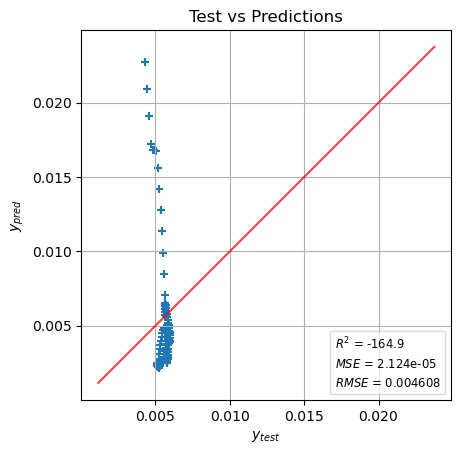

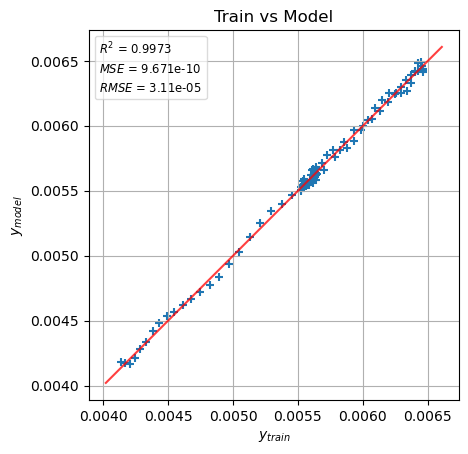

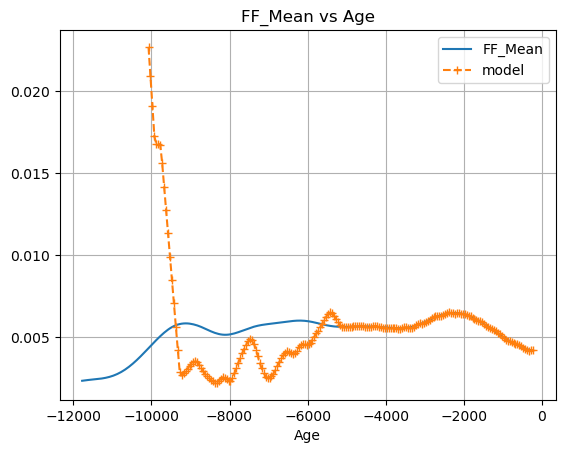

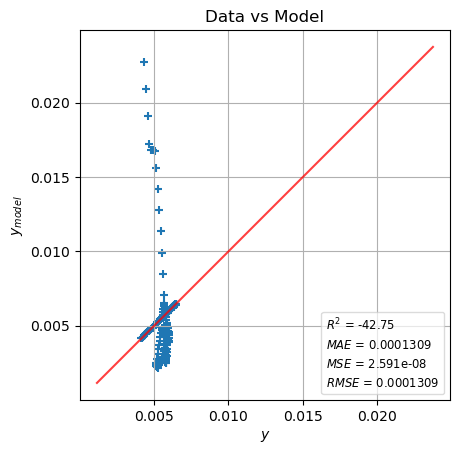

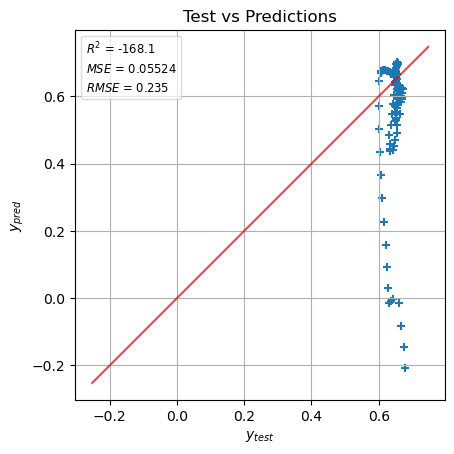

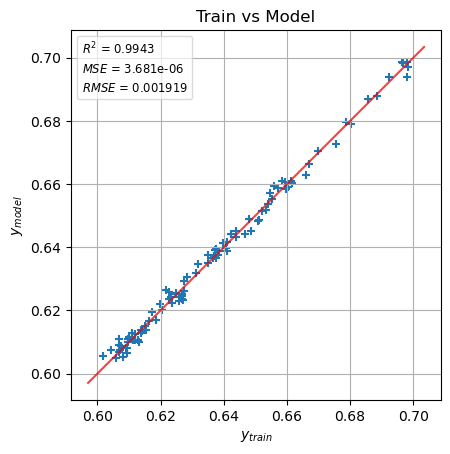

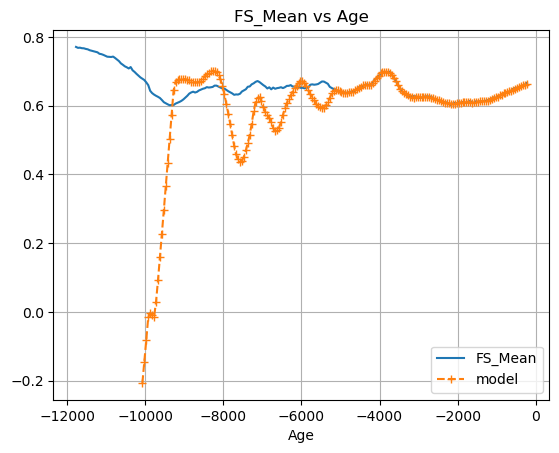

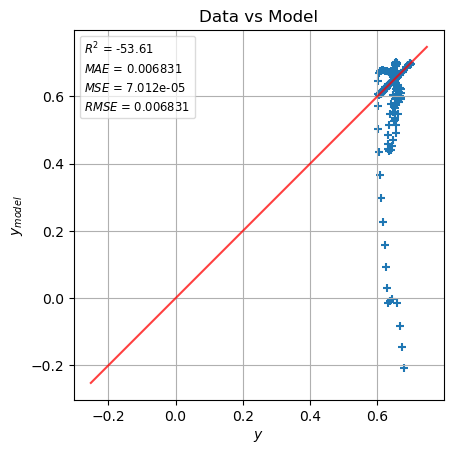

In [21]:
# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Create features X and target y.
features = df_data.columns.values[1:-3]
y_target=['FF_Mean','FS_Mean']

for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]
    # Create features X and target y.


    # Split the dataset into training (usually 75%) and testing (25%) sets.
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
    
 
    tt=floor(len(X)*0.50)
    # tt=floor(len(X)*(1-0.50))

    # X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]
    X_train, X_test, y_train, y_test = X[tt:],X[:tt],y[tt:],y[:tt]

    # Fit and transform training data.
    X_train_scaled = scaler.fit_transform(X_train)   # X_train
    X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
    # Also transform test data.
    X_test_scaled = scaler.transform(X_test)    # X_test 
    X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ############ performance of model #################""
    # Calculate and print R^2 score.
    r2 = r2_score(y_test, y_pred)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    print(f"Root mean squared error: {rmse}")
    # accuracy = accuracy_score(y_test,y_pred)
    # print(f"Accuracy score: {accuracy:.4f}")

    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("Intercept:", model.intercept_)

    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("\nFeature Coefficients:\n", coeff_df)

    ############# plot correlation plots #######################
    fig, ax = plt.subplots()

    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel(r'$y_{test}$')
    ax.set_ylabel(r'$y_{pred}$')
    ax.set_title('Test vs Predictions')
    # squared plot
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # create a list with two empty handles (or more if needed)
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    ############ plot for train data #################
    # model for X_train
    df_model_train=X_train_scaled
    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
    # add all columns 
    df_model_train = df_model_train.sum(axis=1)

    fig, ax = plt.subplots()

    ax.scatter(x=y_train,y=b+df_model_train,marker='+')
    ax.set_xlabel(r'$y_{train}$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Train vs Model')
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()

    r2 = r2_score(y_train, b+df_model_train)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_train, b+df_model_train)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    #### dataframe of obtained model
    df_model=X
    X_scaled=scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]

    # add all columns 
    df_model = df_model.sum(axis=1)

    # figure
    fig, ax = plt.subplots()
    df_annual.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_data['Age'],b+df_model,label='model',marker='+',linestyle='--')
    ax.legend()
    ax.set_title(y_target[k] +' vs Age')
    ax.grid()
    # ax.vlines(x=df_data['Age'][tt],ymin=min(df_data[y_target[k]]),ymax=max(df_data[y_target[k]]),color='r',linestyle='--')


    fig, ax = plt.subplots()
    ax.scatter(x=y,y=b+df_model,marker='+')
    ax.set_xlabel(r'$y$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Data vs Model')
    ax.set_aspect('equal',adjustable='box')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # Calculate and print R^2 score.
    r2 = r2_score(y, b+df_model)
    mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 4

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MAE$ = {0:.4g}'.format(mae) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)


# Differential model


## not normalized

### merge data with data_diff

In [64]:
df_data = pd.merge(Pollen50Reg, df_annual, how='inner', on=['Age', 'Age'])
array_age=df_data.Age.values
df_data=df_data.dropna()

array_age=df_data.Age

df_data_diff=df_data.diff(periods=1,axis=0)
df_data_diff.columns=df_data.columns+'_diff'
df_data_diff.Age_diff = array_age
df_data_diff.rename(columns={'Age_diff':'Age'}, inplace=True)


df_all = pd.merge(df_data,df_data_diff,how='inner',on=['Age','Age'])


### test train split

In [ ]:
def LinearRegression_sklearn(df_data,X_features,y_target_name,split_random=True,time_split=100):
    '''
    Arguments :
    - df_data : dataframe of the data with all features wanted and targets
    - X_features : name of features as list or array
    - y_target_name : name of target value to predict
    Returns : 
    - [df_model, df_model_train,y_pred, y_train, y_test, b, coeff_df, [r2,mae,mse,rmse]]
    - df_model : model timeseries for df_data['Age']
    - df_model_train : model for train set
    - y_pred : model for test set
    - b : model intercept
    - coeff_df : model's coefficient
    - [r2,mae,mse,rmse] : model's performance
    '''
    # Import train_test_split.
    from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
    cv=LeaveOneOut()
    # Import StandardScaler.
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
    #à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
    # dominent le modèle en raison de différences d'échelle.
    # Import LinearRegression.
    from sklearn.linear_model import LinearRegression
    # Import metrics.
    from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
    
    features = X_features
    # df_data.columns[1:-3].append(df_data_diff.columns[1:-3]).values
    y_target=[y_target_name] #,'FF_Mean_diff','FS_Mean','FS_Mean_diff']

    df_dataa=df_data[1:]
    for k in range(len(y_target)):
        X = df_dataa[features]
        y = df_dataa[y_target[k]]
        # Create features X and target y.

        # Split the dataset into training (usually 75%) and testing (25%) sets.
        if split_random==True:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
        else:
            tt=time_split
            X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

        # Fit and transform training data.
        X_train_scaled = scaler.fit_transform(X_train)   # X_train
        X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
        # Also transform test data.
        X_test_scaled = scaler.transform(X_test)    # X_test 
        X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

        # Instantiate linear regression model.
        model = LinearRegression()
        # Fit the model to the training data.
        model.fit(X_train_scaled, y_train)

        # Make predictions on the testing data.
        y_pred = model.predict(X_test_scaled)
        # coefficient of model
        b=model.intercept_
        coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
        # train vs model data
        df_model_train=X_train_scaled
        # multiply all columns with their respective coefficient
        for i in range(len(coeff_df.Coefficient)):
            df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
        # add all columns 
        df_model_train = df_model_train.sum(axis=1)
        #### dataframe of obtained model
        df_model=X
        X_scaled=scaler.transform(X)
        X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

        # multiply all columns with their respective coefficient
        for i in range(len(coeff_df.Coefficient)):
            df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
        # add all columns 
        df_model = df_model.sum(axis=1)

        [r2,mae,mse,rmse]=[r2_score(y, b+df_model),
                        abs(cross_score(model,X,y)).mean()[1],
                        abs(cross_score(model,X,y)).mean()[2],
                        abs(cross_score(model,X,y)).mean()[3]]


        return df_model, df_model_train, y_pred, y_train, y_test, b, coeff_df, [r2,mae,mse,rmse]
        


R-squared: 0.9563192413424808
Mean squared error: 2.5005429662412764e-05
Root mean squared error: 0.0050005429367632435
Intercept: 0.6418753869578232

Feature Coefficients:
               Feature  Coefficient
0               Abies    -0.014879
1        Cupressaceae     0.002627
2               Larix    -0.046496
3               Picea     0.007896
4               Pinus     0.000716
5               Alnus     0.010978
6              Betula    -0.019254
7             Populus    -0.021644
8             Quercus    -0.029095
9               Salix    -0.005459
10              Ulmus    -0.005180
11           Ambrosia    -0.000840
12          Artemisia     0.008926
13         Asteraceae    -0.001155
14        Chenopodium    -0.001849
15         Cyperaceae     0.001733
16            Poaceae    -0.015017
17           Aquatics     0.000473
18                 TS     0.019570
19              PRECT     0.015611
20              human    -0.007737
21         Abies_diff    -0.001078
22  Cupressaceae_diff

C:\Users\leoge\AppData\Local\Temp\ipykernel_18856\4262616483.py:149: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


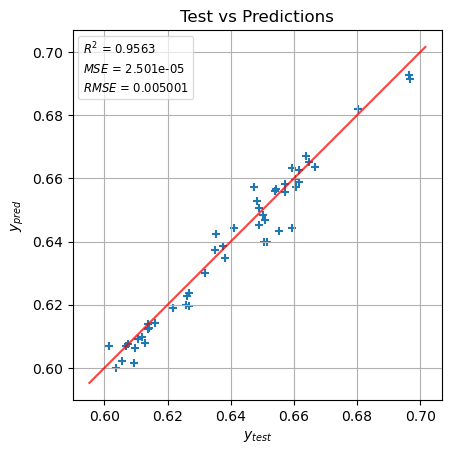

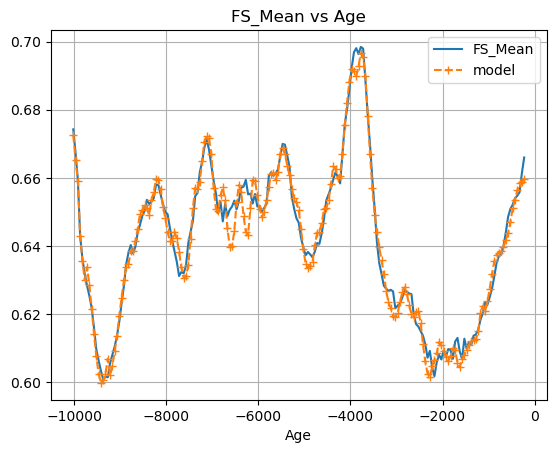

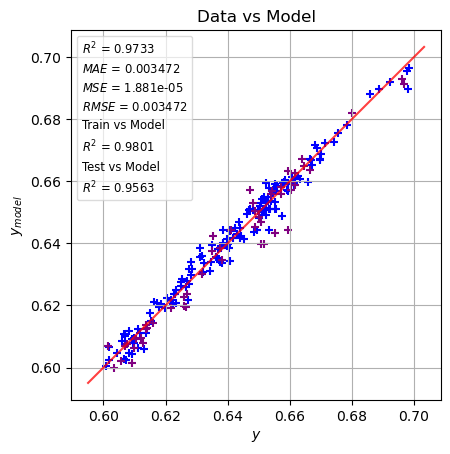

In [ ]:
# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Create features X and target y.
# features = df_data.columns.values[1:-2]
features = df_data.columns[1:-3].append(df_data_diff.columns[1:-3]).values
y_target=['FS_Mean'] #,'FF_Mean_diff','FS_Mean','FS_Mean_diff']

df_dataa=df_all[1:]
for k in range(len(y_target)):
    X = df_dataa[features]
    y = df_dataa[y_target[k]]
    # Create features X and target y.

    # Split the dataset into training (usually 75%) and testing (25%) sets.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
    # tt=100
    # X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    # Fit and transform training data.
    X_train_scaled = scaler.fit_transform(X_train)   # X_train
    X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
    # Also transform test data.
    X_test_scaled = scaler.transform(X_test)    # X_test 
    X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("Intercept:", model.intercept_)
    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("\nFeature Coefficients:\n", coeff_df)

    ############ plot for train data #################
    # model for X_train
    df_model_train=X_train_scaled
    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
    # add all columns 
    df_model_train = df_model_train.sum(axis=1)
    #### dataframe of obtained model
    df_model=X
    X_scaled=scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
    # add all columns 
    df_model = df_model.sum(axis=1)

    # figure
    fig, ax = plt.subplots()
    df_dataa.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_dataa['Age'],b+df_model,label='model',marker='+',linestyle='--')
    ax.legend()
    ax.set_title(y_target[k] +' vs Age')
    ax.grid()

    fig, ax = plt.subplots()
    # ax.scatter(x=y,y=b+df_model,marker='+')
    ax.scatter(x=y_train,y=b+df_model_train,marker='+',color='b',label='train')
    ax.scatter(x=y_test,y=y_pred,marker='+',color='purple',label='test')
    ax.set_xlabel(r'$y$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Data vs Model')
    ax.legend()
    ax.set_aspect('equal',adjustable='box')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # Calculate and print R^2 score.
    r2 = r2_score(y, b+df_model)
    mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 8
    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MAE$ = {0:.4g}'.format(mae) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
    labels.append('Train vs Model' )
    r2 = r2_score(y_train, b+df_model_train)
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('Test vs Model' )
    r2 = r2_score(y_test, y_pred)
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)


C:\Users\leoge\AppData\Local\Temp\ipykernel_18856\3308461484.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(model,X,y)).mean()[1],
C:\Users\leoge\AppData\Local\Temp\ipykernel_18856\3308461484.py:83: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(model,X,y)).mean()[2],
C:\Users\leoge\AppData\Local\Temp\ipykernel_18856\3308461484.py:84: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abs(cross_score(

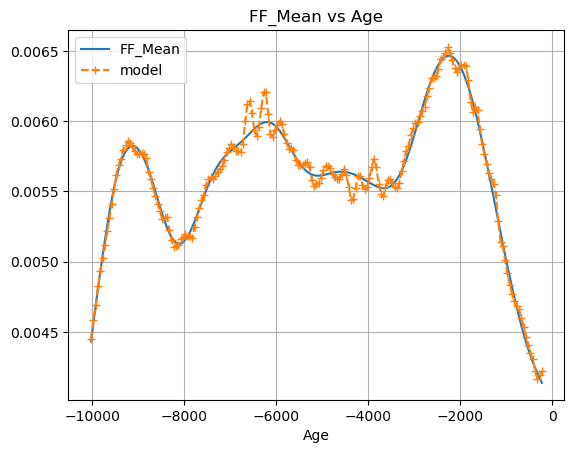

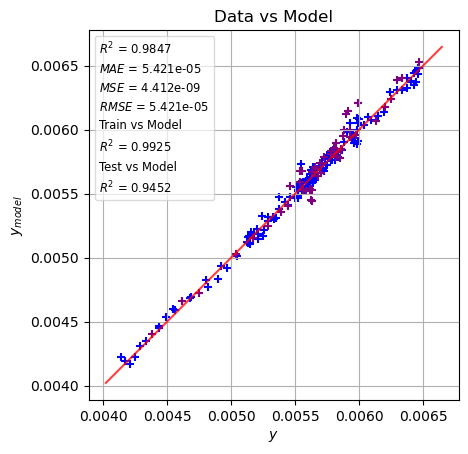

In [69]:

feats=df_data.columns[1:-3].append(df_data_diff.columns[1:-3]).values

[df_model, df_model_train,y_pred, y_train, y_test, b, coeff_df, [r2,mae,mse,rmse]] = LinearRegression_sklearn(df_data=df_all,X_features=feats, y_target_name='FF_Mean',split_random=True,)

# from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
# cv=LeaveOneOut()
# # Import StandardScaler.
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
# #à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# # dominent le modèle en raison de différences d'échelle.
# # Import LinearRegression.
# from sklearn.linear_model import LinearRegression
# # Import metrics.
# from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# # Create features X and target y.
# # features = df_data.columns.values[1:-2]
# features = df_data.columns[1:-3].append(df_data_diff.columns[1:-3]).values
# y_target=['FS_Mean'] #,'FF_Mean_diff','FS_Mean','FS_Mean_diff']

# df_dataa=df_all[1:]
# for k in range(len(y_target)):
#     X = df_dataa[features]
#     y = df_dataa[y_target[k]]
#     # Create features X and target y.

#     # Split the dataset into training (usually 75%) and testing (25%) sets.
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
#     # tt=100
#     # X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

#     # Fit and transform training data.
#     X_train_scaled = scaler.fit_transform(X_train)   # X_train
#     X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
#     # Also transform test data.
#     X_test_scaled = scaler.transform(X_test)    # X_test 
#     X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

#     # Instantiate linear regression model.
#     model = LinearRegression()
#     # Fit the model to the training data.
#     model.fit(X_train_scaled, y_train)

#     # Make predictions on the testing data.
#     y_pred = model.predict(X_test_scaled)

#     ########### linear regression coefficient ##########""
#     b=model.intercept_
#     print("Intercept:", model.intercept_)
#     coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
#     print("\nFeature Coefficients:\n", coeff_df)

#     ############ plot for train data #################
#     # model for X_train
#     df_model_train=X_train_scaled
#     # multiply all columns with their respective coefficient
#     for i in range(len(coeff_df.Coefficient)):
#         df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
#     # add all columns 
#     df_model_train = df_model_train.sum(axis=1)
#     #### dataframe of obtained model
#     df_model=X
#     X_scaled=scaler.transform(X)
#     X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

#     # multiply all columns with their respective coefficient
#     for i in range(len(coeff_df.Coefficient)):
#         df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
#     # add all columns 
#     df_model = df_model.sum(axis=1)

# figure
df_dataa=df_all[1:]
y_target='FF_Mean'
fig, ax = plt.subplots()
df_dataa.plot(x='Age',y=y_target,ax=ax)
ax.plot(df_dataa['Age'],b+df_model,label='model',marker='+',linestyle='--')
ax.legend()
ax.set_title(y_target +' vs Age')
ax.grid()

fig, ax = plt.subplots()
# ax.scatter(x=y,y=b+df_model,marker='+')
ax.scatter(x=y_train,y=b+df_model_train,marker='+',color='b',label='train')
ax.scatter(x=y_test,y=y_pred,marker='+',color='purple',label='test')
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Data vs Model')
ax.legend()
ax.set_aspect('equal',adjustable='box')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# Calculate and print R^2 score.
# r2 = r2_score(y, b+df_model)
# mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                lw=0, alpha=0)] * 8
# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
labels.append('Train vs Model' )
r2 = r2_score(y_train, b+df_model_train)
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('Test vs Model' )
r2 = r2_score(y_test, y_pred)
labels.append('$R^2$ = {0:.4g}'.format(r2) )
# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
        fancybox=True, framealpha=0.7, 
        handlelength=0, handletextpad=0)


In [44]:
FF_val=np.array([ 2.75515818e-04, -2.60534289e-04,  5.01765284e-04, -4.83793608e-04,
        1.84319800e-05, -4.35887506e-04,  4.55678842e-04,  1.80870835e-04,
        3.16731189e-04, -1.30492509e-04, -5.59427194e-05,  6.90026907e-05,
       -1.14859585e-04, -5.20699514e-05, -1.77977269e-04,  3.84904100e-05,
        5.45541112e-04,  2.42037144e-05, -8.71917669e-05, -2.67098842e-04,
        5.06212301e-05])

FF_val_diff=np.array([ 6.57104147e-05, -1.14865837e-04,  1.00532984e-05,  5.47124291e-05,
        1.94161312e-05,  7.31280914e-05, -2.76174174e-05, -4.13244816e-05,
        5.31611356e-05, -7.90132013e-05, -2.94055497e-06,  7.52069887e-05,
        8.99715166e-06,  4.66032877e-05,  2.68470151e-05, -6.11692078e-05,
       -1.22842487e-04, -2.77897765e-05,  3.67142192e-06,  1.22760937e-05,
        1.13902604e-04])

FS_val = np.array([-0.01487913,  0.00262685, -0.04649586,  0.00789609,  0.00071616,
        0.01097841, -0.01925407, -0.02164407, -0.02909548, -0.00545928,
       -0.00517972, -0.00083972,  0.00892566, -0.00115455, -0.00184877,
        0.0017334 , -0.015017  ,  0.00047261,  0.01956965,  0.01561081,
       -0.00773693])

FS_val_diff= np.array([-0.00107815,  0.00540859,  0.00129635, -0.00369473,  0.00287348,
       -0.00334763,  0.00269757,  0.00309146,  0.00473711,  0.00445048,
        0.0017338 , -0.00431036, -0.0006241 , -0.00110924, -0.00178326,
        0.00315947,  0.00457608,  0.00211319, -0.0010205 , -0.00062177,
        0.00366372])

feature=np.array(['Abies', 'Cupressaceae', 'Larix', 'Picea', 'Pinus', 'Alnus',
       'Betula', 'Populus', 'Quercus', 'Salix', 'Ulmus', 'Ambrosia',
       'Artemisia', 'Asteraceae', 'Chenopodium', 'Cyperaceae', 'Poaceae',
       'Aquatics', 'TS', 'PRECT', 'human'], dtype=object)

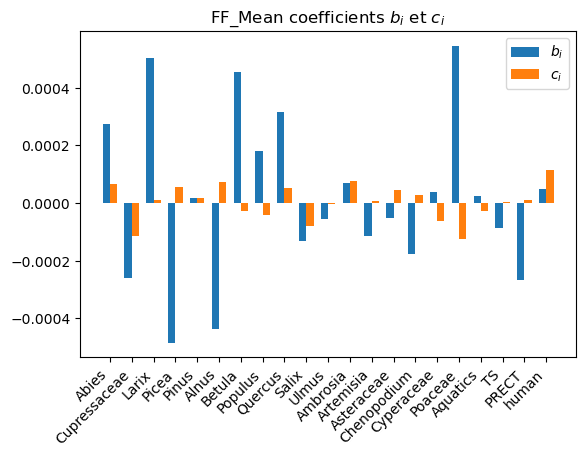

In [45]:
fig, ax = plt.subplots()

# feature = FF_coeff.Feature
v1, v2 = FF_val , FF_val_diff
w, x = 0.4, 1.2*np.arange(len(feature))

ax.bar(x - w/2, v1, w, label='$b_i$')
ax.bar(x + w/2, v2, w, label='$c_i$')

ax.set_xticks(x, feature)
# plt.ylabel('Va')
ax.set_title('FF_Mean coefficients $b_i$ et $c_i$')
ax.legend()


# ax.bar(FF_coeff.Feature,[FF_coeff.Coefficient,FF_coeff_smooth.Coefficient])
fig.autofmt_xdate(rotation=45)

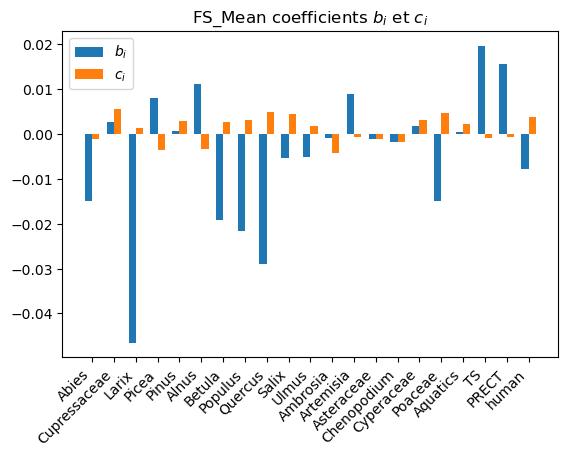

In [46]:
fig, ax = plt.subplots()


v1, v2 = FS_val , FS_val_diff
w, x = 0.4, 1.2*np.arange(len(feature))

ax.bar(x - w/2, v1, w, label='$b_i$')
ax.bar(x + w/2, v2, w, label='$c_i$')

ax.set_xticks(x, feature)
# plt.ylabel('Va')
ax.set_title('FS_Mean coefficients $b_i$ et $c_i$')
ax.legend()


# ax.bar(FF_coeff.Feature,[FF_coeff.Coefficient,FF_coeff_smooth.Coefficient])
fig.autofmt_xdate(rotation=45)

In [47]:
mod=np.array(df_all['FS_Mean'][0])
mod

array(0.67792186)

In [48]:
mod=np.array(df_all['FS_Mean'][0])

for i in range (1,len(df_all)):
    if i==1:
        var=mod+50*df_all['FS_Mean_diff'][i]
        mod=np.append(mod,var)
    else:
        var=mod[i-1]+50*df_all['FS_Mean_diff'][i]
        mod=np.append(mod,var)

mod

array([ 0.67792186,  0.49493285,  0.14815166, -0.24865387, -1.07481387,
       -1.41079661, -1.62703076, -1.80066443, -1.94830069, -2.12289039,
       -2.41270823, -2.72961286, -2.89386851, -3.04332944, -3.17395084,
       -3.13550606, -3.14202604, -2.93439236, -2.81214566, -2.69055476,
       -2.53503989, -2.32562321, -2.05764294, -1.80509281, -1.48425012,
       -1.31324523, -1.20199132, -1.32439439, -1.22556881, -1.02085079,
       -0.90510038, -0.77506231, -0.70257419, -0.53921717, -0.60005077,
       -0.56448309, -0.51092002, -0.31579752, -0.32188536, -0.46235725,
       -0.60550875, -0.71862859, -0.74963723, -0.95123417, -1.13551729,
       -1.29320852, -1.44764996, -1.65675017, -1.59740983, -1.61670029,
       -1.50216626, -1.17219303, -1.00629749, -0.84986069, -0.48407772,
       -0.43826994, -0.13167241,  0.01551402,  0.23029749,  0.34712873,
        0.1964123 , -0.02581021, -0.25517493, -0.44420462, -0.73415863,
       -0.56546174, -0.85526338, -0.60271447, -0.77811875, -0.68

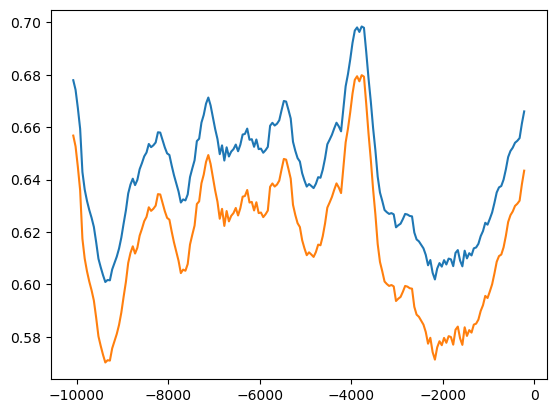

In [49]:
plt.plot(df_all.Age,df_all.FS_Mean)
plt.plot(df_all.Age,mod*np.std(df_all.FS_Mean)+np.mean(df_all.FS_Mean))


### pred

Cas FS_Mean
R-squared: -6.11496894300941
Mean squared error: 0.0047010975761277
Root mean squared error: 0.06856455043335222
Intercept: 0.645443631524

Feature Coefficients:
               Feature  Coefficient
0               Abies     0.025304
1        Cupressaceae    -0.005252
2               Larix     0.010426
3               Picea    -0.036266
4               Pinus     0.006742
5               Alnus    -0.007505
6              Betula    -0.009185
7             Populus    -0.005657
8             Quercus    -0.003156
9               Salix    -0.014378
10              Ulmus     0.003199
11           Ambrosia     0.021794
12          Artemisia    -0.001195
13         Asteraceae    -0.004784
14        Chenopodium    -0.011736
15         Cyperaceae    -0.002217
16            Poaceae     0.006864
17           Aquatics     0.000314
18                 TS     0.006424
19              PRECT    -0.005621
20              human     0.006753
21         Abies_diff    -0.000316
22  Cupressaceae_dif

C:\Users\leoge\AppData\Local\Temp\ipykernel_18856\1500119900.py:188: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]


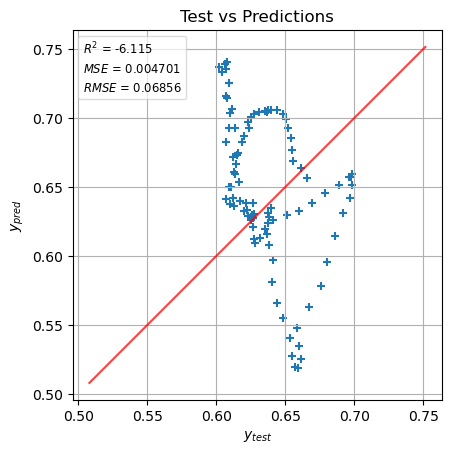

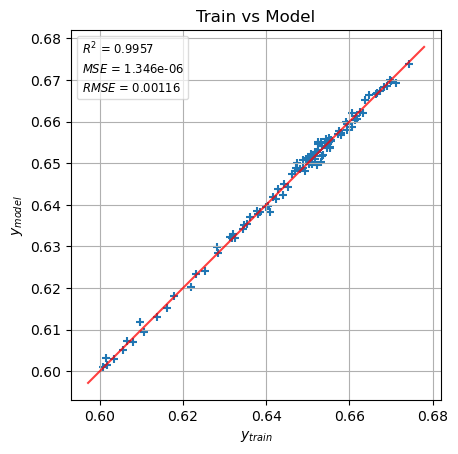

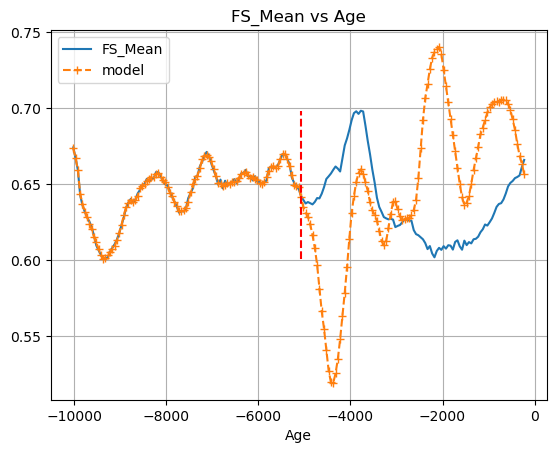

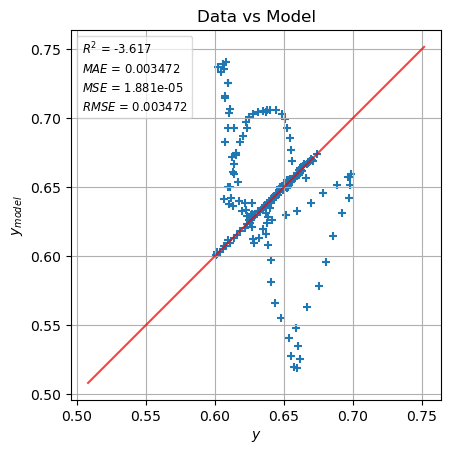

In [50]:
# df_data=df_all[1:]

# Import train_test_split.
from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Create features X and target y.
# features = df_data.columns.values[1:-2]
features = df_data.columns[1:-3].append(df_data_diff.columns[1:-3]).values
y_target=['FS_Mean']#,'FF_Mean_diff','FS_Mean','FS_Mean_diff']

df_data=df_all[1:]
for k in range(len(y_target)):
    X = df_data[features]
    y = df_data[y_target[k]]
    # Create features X and target y.


    # Split the dataset into training (usually 75%) and testing (25%) sets.
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size_test, random_state=42)
    tt=100
    X_train, X_test, y_train, y_test = X[:tt],X[tt:],y[:tt],y[tt:]

    # Fit and transform training data.
    X_train_scaled = scaler.fit_transform(X_train)   # X_train
    X_train_scaled = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X_train.columns)
    # Also transform test data.
    X_test_scaled = scaler.transform(X_test)    # X_test 
    X_test_scaled = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X_test.columns)

    # Instantiate linear regression model.
    model = LinearRegression()
    # Fit the model to the training data.
    model.fit(X_train_scaled, y_train)

    # Make predictions on the testing data.
    y_pred = model.predict(X_test_scaled)

    ############ performance of model #################""
    print('Cas',y_target[k])
    # Calculate and print R^2 score.
    r2 = r2_score(y_test, y_pred)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    print(f"Root mean squared error: {rmse}")
    # accuracy = accuracy_score(y_test,y_pred)
    # print(f"Accuracy score: {accuracy:.4f}")

    ########### linear regression coefficient ##########""
    b=model.intercept_
    print("Intercept:", model.intercept_)

    coeff_df = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_})
    print("\nFeature Coefficients:\n", coeff_df)

    ############# plot correlation plots #######################
    
    
    # plot test vs prediction
    fig, ax = plt.subplots()
    ax.scatter(x=y_test,y=y_pred,marker='+')
    ax.set_xlabel(r'$y_{test}$')
    ax.set_ylabel(r'$y_{pred}$')
    ax.set_title('Test vs Predictions')
    # squared plot
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # create a list with two empty handles (or more if needed)
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    ############ plot for train data #################
    # model for X_train
    df_model_train=X_train_scaled
    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model_train.iloc[:,i] = X_train_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]
    # add all columns 
    df_model_train = df_model_train.sum(axis=1)

    # plot train vs model
    fig, ax = plt.subplots()
    ax.scatter(x=y_train,y=b+df_model_train,marker='+')
    ax.set_xlabel(r'$y_{train}$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Train vs Model')
    ax.set_aspect('equal',adjustable='box')
    ax=plt.gca()
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()

    r2 = r2_score(y_train, b+df_model_train)
    print(f"R-squared: {r2}")
    # Calculate and print MSE.
    mse = mean_squared_error(y_train, b+df_model_train)
    print(f"Mean squared error: {mse}")
    # Calculate and print RMSE.
    rmse = mse ** 0.5
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 3

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)

    #### dataframe of obtained model
    df_model=X
    X_scaled=scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    # multiply all columns with their respective coefficient
    for i in range(len(coeff_df.Coefficient)):
        df_model.iloc[:,i] = X_scaled.iloc[:,i]*coeff_df.Coefficient.values[i]

    # add all columns 
    df_model = df_model.sum(axis=1)

    # figure time series
    fig, ax = plt.subplots()
    df_data.plot(x='Age',y=y_target[k],ax=ax)
    ax.plot(df_data['Age'],b+df_model,label='model',marker='+',linestyle='--')
    ax.legend()
    ax.set_title(y_target[k] +' vs Age')
    ax.vlines(x=df_data.Age[tt],ymin=np.min(df_data[y_target[k]]),ymax=np.max(df_data[y_target[k]]),color='r',linestyle='--')
    ax.grid()

    # Data vs Model
    fig, ax = plt.subplots()
    ax.scatter(x=y,y=b+df_model,marker='+')
    ax.set_xlabel(r'$y$')
    ax.set_ylabel(r'$y_{model}$')
    ax.set_title('Data vs Model')
    ax.set_aspect('equal',adjustable='box')
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    # now plot both limits against eachother
    ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
    ax.grid()
    # Calculate and print R^2 score.
    r2 = r2_score(y, b+df_model)
    mae,mse,rmse=abs(cross_score(model,X,y)).mean()[1],abs(cross_score(model,X,y)).mean()[2],abs(cross_score(model,X,y)).mean()[3]
    handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                    lw=0, alpha=0)] * 4

    # create the corresponding number of labels (= the text you want to display)
    labels = []#"R-squared: {r2}"
    labels.append('$R^2$ = {0:.4g}'.format(r2) )
    labels.append('$MAE$ = {0:.4g}'.format(mae) )
    labels.append('$MSE$ = {0:.4g}'.format(mse) )
    labels.append('$RMSE$ = {0:.4g}'.format(rmse) )

    # create the legend, supressing the blank space of the empty line symbol and the
    # padding between symbol and label by setting handlelenght and handletextpad
    ax.legend(handles, labels, loc='best', fontsize='small', 
            fancybox=True, framealpha=0.7, 
            handlelength=0, handletextpad=0)


## normalized

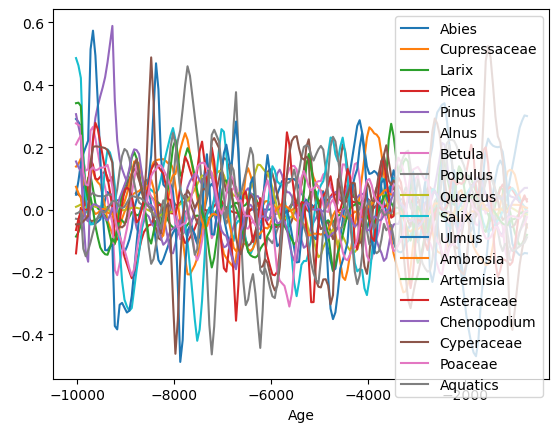

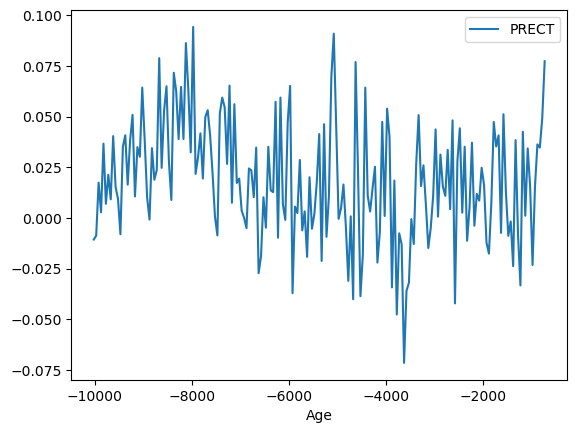

In [34]:
df=df_data

normalized_df=(df-df.mean())/df.std()


normalized_df_diff=normalized_df.diff(periods=1, axis=0)
normalized_df_diff['Age']=array_age
normalized_df_diff= normalized_df_diff.dropna()


(normalized_df_diff).plot(x='Age',y=Pollen50Reg.columns[1:])
(normalized_df_diff).plot(x='Age',y=['PRECT'])

normalized_df_diff=normalized_df_diff.dropna()
normalized_df_diff.columns=normalized_df_diff.columns+'_diff'


In [35]:
normalized_df_diff

,Age_diff,Abies_diff,Cupressaceae_diff,Larix_diff,Picea_diff,Pinus_diff,Alnus_diff,Betula_diff,Populus_diff,Quercus_diff,...,Chenopodium_diff,Cyperaceae_diff,Poaceae_diff,Aquatics_diff,TS_diff,PRECT_diff,human_diff,BB_Mean_diff,FF_Mean_diff,FS_Mean_diff
262,-10025.0,0.290282,0.137813,-0.086400,-0.140277,0.305813,0.052334,0.276436,-0.029356,0.008916,...,0.154326,-0.047291,0.208642,-0.013022,0.176454,-0.010601,0.024111,0.036236,0.276996,-0.287436
263,-9975.0,0.280923,0.146837,-0.072230,-0.061122,0.267781,0.047727,0.271077,-0.031247,0.012256,...,0.135984,-0.047066,0.223859,-0.009773,0.133783,-0.008676,0.023790,0.043757,0.273016,-0.258640
264,-9925.0,0.264925,0.163710,-0.049174,0.005830,0.232346,0.041432,0.267346,-0.028887,0.016785,...,0.122568,-0.044819,0.237773,-0.003284,0.148942,0.017473,0.022938,0.028566,0.267250,-0.286743
265,-9875.0,0.093486,0.082605,-0.003157,-0.003626,-0.028574,-0.004847,0.156451,-0.019817,0.004584,...,0.009176,-0.037710,0.120915,-0.124985,0.178963,0.002825,0.022826,0.016095,0.259688,-0.298538
266,-9825.0,0.018661,0.073387,0.049224,0.028201,-0.133638,-0.023372,0.124929,-0.009051,0.007302,...,-0.030811,-0.029266,0.080604,-0.149566,0.152062,0.036686,0.025173,0.008513,0.250341,-0.307185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,-925.0,0.222822,0.079829,-0.097042,0.035880,0.032598,-0.029778,-0.093094,-0.103003,-0.005313,...,0.044438,-0.247063,-0.026610,-0.123455,0.004025,0.015460,-0.058834,-0.101430,-0.183634,0.124934
445,-875.0,0.262468,0.042235,-0.115115,0.022870,0.026145,-0.011299,-0.069383,-0.072309,-0.009819,...,0.053820,-0.176850,-0.028463,-0.117495,-0.011865,0.036321,-0.071440,-0.146353,-0.180078,0.070157
446,-825.0,0.284738,0.005948,-0.108860,0.026549,0.018289,-0.008574,-0.056093,-0.047945,-0.011944,...,0.061802,-0.128328,-0.019281,-0.111534,-0.014254,0.034751,-0.084285,-0.082198,-0.176057,0.154357
447,-775.0,0.301922,-0.029955,-0.095485,0.035111,0.010024,-0.010460,-0.045852,-0.025433,-0.013373,...,0.069373,-0.086155,-0.006871,-0.105574,0.003304,0.049269,-0.098055,-0.061360,-0.171699,0.155397


In [36]:
def threshold(x,thresh,diff_max):
    val=0
    max_int=floor(diff_max/thresh)
    for i in range (-max_int,max_int,1):
        if (x <= i*thresh + thresh/2) and (x > i*thresh + (-thresh/2)):
            val=i
        else:
            val=val
    return val


 

In [37]:
df_diff_max= normalized_df_diff.max()

diff_max=max(df_diff_max[1:])
diff_max

0.5886317928274067

In [38]:
normalized_df_diff_threshold = normalized_df_diff.map(threshold,thresh = 0.25,
                                                      diff_max=diff_max)

normalized_df_diff_threshold["Age"]=df_data['Age']

In [43]:
normalized_df_diff_threshold.columns

Index(['Age_diff', 'Abies_diff', 'Cupressaceae_diff', 'Larix_diff',
       'Picea_diff', 'Pinus_diff', 'Alnus_diff', 'Betula_diff', 'Populus_diff',
       'Quercus_diff', 'Salix_diff', 'Ulmus_diff', 'Ambrosia_diff',
       'Artemisia_diff', 'Asteraceae_diff', 'Chenopodium_diff',
       'Cyperaceae_diff', 'Poaceae_diff', 'Aquatics_diff', 'TS_diff',
       'PRECT_diff', 'human_diff', 'BB_Mean_diff', 'FF_Mean_diff',
       'FS_Mean_diff', 'Age'],
      dtype='object')

<Axes: xlabel='Age'>

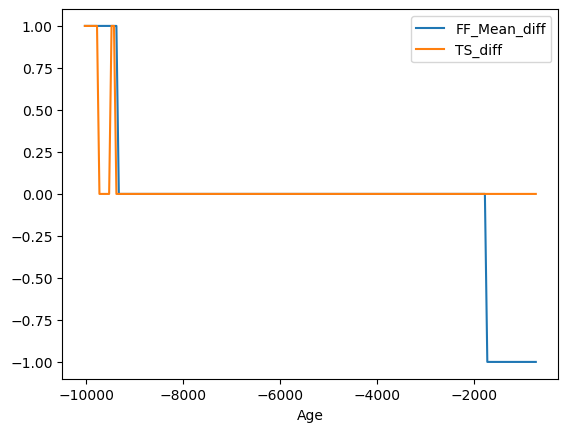

In [49]:
normalized_df_diff_threshold.plot(x='Age',y=['FF_Mean_diff','TS_diff'])

<Axes: xlabel='Age'>

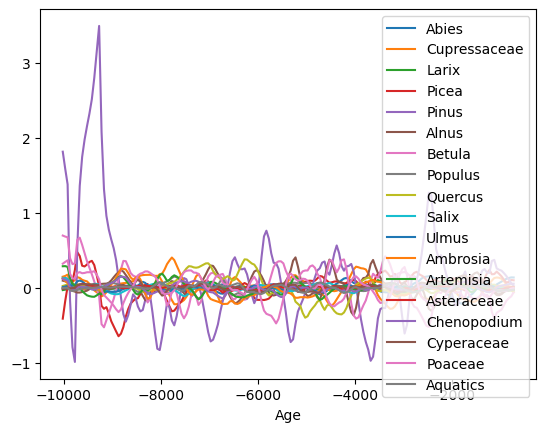

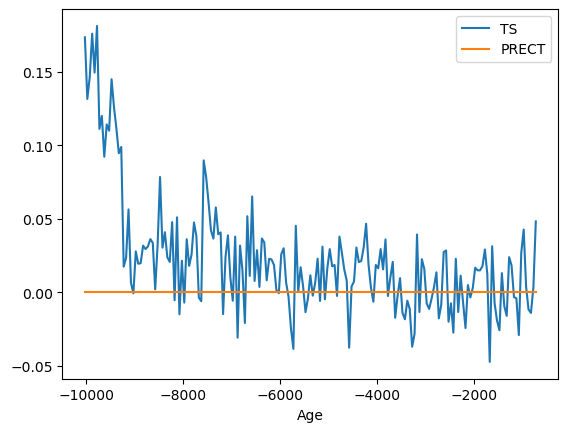

In [40]:
# differention between i and i-1
df_data_diff= df_data.diff(periods=1, axis=0)
# assign the correct age data (diff gives -50 at every index)
df_data_diff['Age']=array_age
df_data_diff= df_data_diff.dropna()

df_data_diff.plot(x='Age',y=Pollen50Reg.columns[1:])
df_data_diff.plot(x='Age',y=['TS','PRECT'])


